# Chapter 71 — Training a Tiny Character-Level GPT on CPU

The previous chapters built a complete GPT architecture, shifted training batches, and all-position cross-entropy loss.

This chapter connects those pieces in the first complete optimization loop.


## Learning goals

By the end of this chapter, you will be able to:

- prepare a character-level dataset;
- create distinct training and validation token sequences;
- sample shifted GPT batches;
- instantiate a CPU-friendly causal transformer;
- run forward, backward, and optimizer steps;
- estimate loss with dropout disabled;
- generate deterministic comparison samples;
- plot training and validation loss; and
- interpret the limitations of a tiny repeated-text experiment.


## What this experiment can show

The model starts with random parameters, so its first sample should look mostly random.

After training, it may learn common characters, spaces, punctuation, short word fragments, and repeated patterns.

It will not produce polished prose after a short CPU run on a small repeated excerpt.

> The goal is to verify the complete learning process, not to approximate a production language model.


## Training configuration

The requested configuration performs exactly 1,000 optimizer updates.

Runtime depends on the CPU, PyTorch build, and available threads.


In [1]:
import torch

device = "cpu"
tiny_character_model_config = {
    "context_length": 64,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
    "batch_size": 16,
    "learning_rate": 0.0003,
    "training_steps": 1000,
    "evaluation_interval": 100,
}

print("device:", device)
print("configuration:")
for configuration_name, configuration_value in tiny_character_model_config.items():
    print(f"  {configuration_name}: {configuration_value}")

device: cpu
configuration:
  context_length: 64
  embedding_dimension: 64
  number_of_attention_heads: 4
  number_of_transformer_blocks: 2
  dropout_rate: 0.1
  batch_size: 16
  learning_rate: 0.0003
  training_steps: 1000
  evaluation_interval: 100


## Prepare embedded text

The notebook embeds a small excerpt from Lewis Carroll's public-domain *Alice's Adventures in Wonderland*.

No network access or external data file is required.

We split the original excerpt before repetition so identical repeated copies cannot appear in both training and validation data.


In [2]:
public_domain_text = """
Alice was beginning to get very tired of sitting by her sister on the bank,
and of having nothing to do. Once or twice she had peeped into the book her
sister was reading, but it had no pictures or conversations in it, and what is
the use of a book, thought Alice, without pictures or conversation?

So she was considering in her own mind, as well as she could, for the hot day
made her feel very sleepy and stupid, whether the pleasure of making a daisy
chain would be worth the trouble of getting up and picking the daisies, when
suddenly a white rabbit with pink eyes ran close by her.

There was nothing so very remarkable in that; nor did Alice think it so very
much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
be too late! But when the rabbit actually took a watch out of its waistcoat
pocket, and looked at it, and then hurried on, Alice started to her feet.

The rabbit-hole went straight on like a tunnel for some way, and then dipped
suddenly down, so suddenly that Alice had not a moment to think about stopping
herself before she found herself falling down what seemed to be a very deep
well.

Either the well was very deep, or she fell very slowly, for she had plenty of
time as she went down to look about her and to wonder what was going to happen
next.
""".strip()

source_split_index = int(0.85 * len(public_domain_text))
training_source_text = public_domain_text[:source_split_index]
validation_source_text = public_domain_text[source_split_index:]
training_text = (training_source_text + "\n\n") * 20
validation_text = (validation_source_text + "\n\n") * 20

print("original excerpt characters:", len(public_domain_text))
print("distinct training source characters:", len(training_source_text))
print("distinct validation source characters:", len(validation_source_text))
print("repeated training characters:", len(training_text))
print("repeated validation characters:", len(validation_text))

original excerpt characters: 1299
distinct training source characters: 1104
distinct validation source characters: 195
repeated training characters: 22120
repeated validation characters: 3940


The validation substring is held out from parameter updates, but repeating both substrings makes this only a teaching-scale estimate of generalization.

A serious experiment would use much more distinct text without artificial repetition.


## Build the character vocabulary

The vocabulary is built from the complete original excerpt so every held-out character has an ID.

Building the vocabulary from all text reveals token identities but does not expose validation sequence order to training.


In [3]:
characters = sorted(set(public_domain_text + "\n"))
character_to_id = {
    character: character_id for character_id, character in enumerate(characters)
}
id_to_character = {
    character_id: character for character, character_id in character_to_id.items()
}
vocabulary_size = len(characters)


def encode_text(text: str, token_to_id: dict[str, int]) -> list[int]:
    return [token_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int], id_to_token: dict[int, str]) -> str:
    return "".join(id_to_token[token_id] for token_id in token_ids)


training_token_ids = torch.tensor(
    encode_text(training_text, character_to_id),
    dtype=torch.long,
    device=device,
)
validation_token_ids = torch.tensor(
    encode_text(validation_text, character_to_id),
    dtype=torch.long,
    device=device,
)
example_text = "Alice"
encoded_example = encode_text(example_text, character_to_id)

print("vocabulary size:", vocabulary_size)
print("characters:", characters)
print("training token shape:", training_token_ids.shape)
print("validation token shape:", validation_token_ids.shape)
print("example IDs:", encoded_example)
print("round trip:", decode_token_ids(encoded_example, id_to_character))

vocabulary size: 38
characters: ['\n', ' ', '!', ',', '-', '.', ';', '?', 'A', 'B', 'E', 'I', 'O', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y']
training token shape: torch.Size([22120])
validation token shape: torch.Size([3940])
example IDs: [8, 25, 23, 17, 19]
round trip: Alice


Each character is one token, so text length and token count are equal.


## Sample shifted batches

The batch sampler chooses start indexes with replacement and constructs all rows with tensor indexing.

A passed `torch.Generator` makes the random start sequence reproducible and independent from dropout randomness.


In [4]:
def get_gpt_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    if batch_size < 1 or context_length < 1:
        raise ValueError("batch_size and context_length must be positive.")

    number_of_valid_starts = token_ids.numel() - context_length
    if number_of_valid_starts < 1:
        raise ValueError("token_ids must be longer than context_length.")

    start_indexes = torch.randint(
        low=0,
        high=number_of_valid_starts,
        size=(batch_size,),
        generator=generator,
        device=token_ids.device,
    )
    position_offsets = torch.arange(context_length, device=token_ids.device)
    input_indexes = start_indexes[:, None] + position_offsets[None, :]
    input_batch = token_ids[input_indexes]
    target_batch = token_ids[input_indexes + 1]
    return input_batch, target_batch


batch_test_generator = torch.Generator(device=device).manual_seed(71)
input_batch, target_batch = get_gpt_training_batch(
    training_token_ids,
    batch_size=tiny_character_model_config["batch_size"],
    context_length=tiny_character_model_config["context_length"],
    generator=batch_test_generator,
)

print("input shape:", input_batch.shape)
print("target shape:", target_batch.shape)
print("shift invariant:", torch.equal(target_batch[:, :-1], input_batch[:, 1:]))
print("decoded input row:")
print(repr(decode_token_ids(input_batch[0].tolist(), id_to_character)))
print("decoded target row:")
print(repr(decode_token_ids(target_batch[0].tolist(), id_to_character)))

input shape: torch.Size([16, 64])
target shape: torch.Size([16, 64])
shift invariant: True
decoded input row:
'for some way, and then dipped\nsuddenly down, so suddenly that Al'
decoded target row:
'or some way, and then dipped\nsuddenly down, so suddenly that Ali'


The target row begins one character later and includes one extra future character at its end.


## Use combined multi-head tensor operations

Earlier chapters represented heads as separate modules to make their roles visible.

For repeated CPU training, this chapter projects all heads together and reshapes them to `[B, H, T, D]`.

`H` is the number of heads, `D = C / H` is head size, and the attention math remains unchanged.

This combined implementation reduces Python overhead without introducing an optimized external attention kernel.


In [5]:
import math


class MultiHeadCausalSelfAttention(torch.nn.Module):
    """Compute causal multi-head attention with combined projections."""

    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int
    context_length: int
    query_projection: torch.nn.Linear
    key_projection: torch.nn.Linear
    value_projection: torch.nn.Linear
    attention_dropout: torch.nn.Dropout
    output_projection: torch.nn.Linear
    output_dropout: torch.nn.Dropout
    causal_mask: torch.Tensor

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError(
                "embedding dimension must divide evenly by the head count."
            )

        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.context_length = context_length
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(
                torch.ones(1, 1, context_length, context_length, dtype=torch.bool)
            ),
        )

    def _split_heads(self, vectors: torch.Tensor) -> torch.Tensor:
        batch_size, current_context_length, _ = vectors.shape
        return vectors.reshape(
            batch_size,
            current_context_length,
            self.number_of_attention_heads,
            self.head_size,
        ).transpose(1, 2)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, current_context_length, _ = input_values.shape
        queries = self._split_heads(self.query_projection(input_values))
        keys = self._split_heads(self.key_projection(input_values))
        values = self._split_heads(self.value_projection(input_values))
        scores = queries @ keys.transpose(-2, -1)
        scaled_scores = scores / math.sqrt(self.head_size)
        allowed = self.causal_mask[
            :, :, :current_context_length, :current_context_length
        ]
        weights = torch.softmax(
            scaled_scores.masked_fill(~allowed, float("-inf")),
            dim=-1,
        )
        attended_values = self.attention_dropout(weights) @ values
        concatenated = attended_values.transpose(1, 2).reshape(
            batch_size, current_context_length, self.embedding_dimension
        )
        projected = self.output_projection(concatenated)
        return self.output_dropout(projected)

The causal mask now has shape `[1, 1, T, T]`, so it broadcasts across both batch items and heads.


## Define the transformer block and model

The model keeps the pre-normalized residual structure from Chapter 67 and the full input-output path from Chapter 68.

ReLU remains a teaching simplification inside the position-wise feedforward network.


In [6]:
class PositionWiseFeedForward(torch.nn.Module):
    """Apply a shared C-to-4C-to-C network at every position."""

    network: torch.nn.Sequential

    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        return self.network(input_values)


class TransformerBlock(torch.nn.Module):
    """Apply one pre-normalized causal transformer block."""

    first_layer_norm: torch.nn.LayerNorm
    attention: MultiHeadCausalSelfAttention
    second_layer_norm: torch.nn.LayerNorm
    feedforward: PositionWiseFeedForward

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.first_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.second_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = PositionWiseFeedForward(embedding_dimension, dropout_rate)

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_change = self.attention(self.first_layer_norm(input_values))
        values_after_attention = input_values + attention_change
        feedforward_change = self.feedforward(
            self.second_layer_norm(values_after_attention)
        )
        return values_after_attention + feedforward_change


class TinyGPT(torch.nn.Module):
    """Map character ID sequences to next-character logits and loss."""

    vocabulary_size: int
    context_length: int
    token_embedding_table: torch.nn.Embedding
    position_embedding_table: torch.nn.Embedding
    embedding_dropout: torch.nn.Dropout
    transformer_blocks: torch.nn.ModuleList
    final_layer_norm: torch.nn.LayerNorm
    output_layer: torch.nn.Linear

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding_table = torch.nn.Embedding(
            vocabulary_size, embedding_dimension
        )
        self.position_embedding_table = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.ModuleList(
            [
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("input IDs must have shape [batch, context].")

        current_context_length = input_token_ids.shape[1]
        if current_context_length < 1:
            raise ValueError("input context cannot be empty.")
        if current_context_length > self.context_length:
            raise ValueError("input exceeds the model context length.")

        token_embeddings = self.token_embedding_table(input_token_ids)
        position_ids = torch.arange(
            current_context_length,
            dtype=torch.long,
            device=input_token_ids.device,
        )
        position_embeddings = self.position_embedding_table(position_ids)
        current_values = self.embedding_dropout(token_embeddings + position_embeddings)
        for block in self.transformer_blocks:
            current_values = block(current_values)

        normalized_values = self.final_layer_norm(current_values)
        vocabulary_logits = self.output_layer(normalized_values)
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                vocabulary_logits.reshape(-1, self.vocabulary_size),
                target_token_ids.reshape(-1),
            )

        return vocabulary_logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator | None = None,
    ) -> torch.Tensor:
        generated_token_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            cropped_input = generated_token_ids[:, -self.context_length :]
            vocabulary_logits, _ = self(cropped_input)
            probabilities = torch.softmax(vocabulary_logits[:, -1], dim=-1)
            next_token_ids = torch.multinomial(
                probabilities, num_samples=1, generator=generator
            )
            generated_token_ids = torch.cat(
                [generated_token_ids, next_token_ids], dim=1
            )

        return generated_token_ids

The model returns logits with shape `[B, T, V]` and computes the mean loss over all `B × T` targets.


## Instantiate and test the model

A fixed initialization seed makes the full training run reproducible on this environment.

The first forward pass verifies shapes before any optimizer update.


In [7]:
def count_parameters(module: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in module.parameters())


torch.manual_seed(71)
model = TinyGPT(
    vocabulary_size=vocabulary_size,
    context_length=tiny_character_model_config["context_length"],
    embedding_dimension=tiny_character_model_config["embedding_dimension"],
    number_of_attention_heads=tiny_character_model_config["number_of_attention_heads"],
    number_of_transformer_blocks=tiny_character_model_config[
        "number_of_transformer_blocks"
    ],
    dropout_rate=tiny_character_model_config["dropout_rate"],
).to(device)
model.eval()
with torch.no_grad():
    initial_logits, initial_loss = model(input_batch, target_batch)

print("parameter count:", count_parameters(model))
print("input shape:", input_batch.shape)
print("target shape:", target_batch.shape)
print("logit shape:", initial_logits.shape)
print("initial batch loss:", initial_loss.item() if initial_loss is not None else None)

parameter count: 108710
input shape: torch.Size([16, 64])
target shape: torch.Size([16, 64])
logit shape: torch.Size([16, 64, 38])
initial batch loss: 3.807142734527588


Training will change parameter values, but these external shapes will remain fixed.


## Define evaluation and generation helpers

Evaluation uses `model.eval()` and `torch.no_grad()` so dropout is disabled and no gradient graph is stored.

Each evaluation call recreates fixed batch generators, making loss checkpoints comparable on the same sampled windows.

Generation also uses its own generator, so sampling text does not change later training randomness.


In [8]:
@torch.no_grad()
def estimate_loss(
    model: TinyGPT,
    training_token_ids: torch.Tensor,
    validation_token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    evaluation_batches: int,
) -> dict[str, float]:
    previous_training_mode = model.training
    model.eval()
    average_losses = {}

    for split_index, (split_name, split_token_ids) in enumerate(
        [("train", training_token_ids), ("validation", validation_token_ids)]
    ):
        evaluation_generator = torch.Generator(device=device).manual_seed(
            7100 + split_index
        )
        split_losses = []
        for _ in range(evaluation_batches):
            input_batch, target_batch = get_gpt_training_batch(
                split_token_ids,
                batch_size=batch_size,
                context_length=context_length,
                generator=evaluation_generator,
            )
            _, loss = model(input_batch, target_batch)
            if loss is None:
                raise RuntimeError("evaluation requires target loss.")
            split_losses.append(loss.item())

        average_losses[split_name] = sum(split_losses) / len(split_losses)

    model.train(previous_training_mode)
    return average_losses


@torch.no_grad()
def generate_text(
    model: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    sampling_seed: int,
) -> str:
    previous_training_mode = model.training
    model.eval()
    prompt_token_ids = torch.tensor(
        [encode_text(prompt, character_to_id)],
        dtype=torch.long,
        device=device,
    )
    sampling_generator = torch.Generator(device=device).manual_seed(sampling_seed)
    generated_token_ids = model.generate(
        prompt_token_ids,
        number_of_new_tokens=number_of_new_tokens,
        generator=sampling_generator,
    )
    model.train(previous_training_mode)
    return decode_token_ids(generated_token_ids[0].tolist(), id_to_character)

Restoring the previous mode prevents evaluation or generation helpers from silently leaving the model in the wrong state.


## Measure the random baseline

Step `0` is evaluated before any parameter update.

The pre-training sample uses the same prompt and sampling seed that later comparison samples will use.


In [9]:
evaluation_batches = 10
batch_size = tiny_character_model_config["batch_size"]
context_length = tiny_character_model_config["context_length"]
baseline_losses = estimate_loss(
    model,
    training_token_ids,
    validation_token_ids,
    batch_size=batch_size,
    context_length=context_length,
    evaluation_batches=evaluation_batches,
)
sample_before_training = generate_text(
    model,
    prompt="Alice",
    number_of_new_tokens=160,
    sampling_seed=7102,
)

print("step 0 training loss:", round(baseline_losses["train"], 4))
print("step 0 validation loss:", round(baseline_losses["validation"], 4))
print("sample before training:")
print(sample_before_training)

step 0 training loss: 3.8054
step 0 validation loss: 3.8098
sample before training:
AlicepSeO;

g krT
fp?lt!e lhd.xppf-lpieBo?Avl;wOcenObtuEtg;pdnBcIrhn
,usbIrysBn?t?.yETB
hdp 
Ordltsc,l,?,hbayorpdwBSd?wgT lshlnhI;
bt,ITvyb
Ic-pm!b-sEtO?lBn!Tvy
tuOg


The random sample is expected to ignore word structure and long-range coherence.


## Run exactly 1,000 optimizer updates

Each update samples a training batch, computes loss, clears old gradients, backpropagates, and calls `optimizer.step()`.

Evaluation happens after updates `100`, `200`, and so on through `1,000`.

Samples are retained at steps `500` and `1,000` to show progress without filling the notebook with repetitive text.


In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=tiny_character_model_config["learning_rate"],
)
training_batch_generator = torch.Generator(device=device).manual_seed(7103)
training_steps = tiny_character_model_config["training_steps"]
evaluation_interval = tiny_character_model_config["evaluation_interval"]
evaluation_steps = [0]
training_loss_history = [baseline_losses["train"]]
validation_loss_history = [baseline_losses["validation"]]
generated_samples = {0: sample_before_training}
first_step_gradient_norm = None
optimizer_updates = 0
model.train()

for step in range(1, training_steps + 1):
    input_batch, target_batch = get_gpt_training_batch(
        training_token_ids,
        batch_size=batch_size,
        context_length=context_length,
        generator=training_batch_generator,
    )
    _, loss = model(input_batch, target_batch)
    if loss is None:
        raise RuntimeError("training requires target loss.")

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    if step == 1:
        squared_gradient_norm = sum(
            parameter.grad.square().sum()
            for parameter in model.parameters()
            if parameter.grad is not None
        )
        first_step_gradient_norm = squared_gradient_norm.sqrt().item()
    optimizer.step()
    optimizer_updates += 1

    if step % evaluation_interval == 0:
        checkpoint_losses = estimate_loss(
            model,
            training_token_ids,
            validation_token_ids,
            batch_size=batch_size,
            context_length=context_length,
            evaluation_batches=evaluation_batches,
        )
        evaluation_steps.append(step)
        training_loss_history.append(checkpoint_losses["train"])
        validation_loss_history.append(checkpoint_losses["validation"])
        print(
            f"step {step:4} | "
            f"train {checkpoint_losses['train']:.4f} | "
            f"validation {checkpoint_losses['validation']:.4f}"
        )

        if step in {500, 1000}:
            generated_samples[step] = generate_text(
                model,
                prompt="Alice",
                number_of_new_tokens=160,
                sampling_seed=7102,
            )
            print(f"sample at step {step}:")
            print(generated_samples[step])

print("optimizer updates:", optimizer_updates)
print("first-step gradient norm:", first_step_gradient_norm)

step  100 | train 2.6927 | validation 2.7194


step  200 | train 2.4104 | validation 2.5015


step  300 | train 2.2842 | validation 2.4346


step  400 | train 2.2078 | validation 2.3900


step  500 | train 2.1361 | validation 2.3658


...

step  700 | train 2.0229 | validation 2.3693


step  800 | train 1.9727 | validation 2.3604


step  900 | train 1.9106 | validation 2.3808


step 1000 | train 1.8399 | validation 2.3866


sample at step 1000:
Alice to ar
g srer aile thlicong fo. ie or wisitot



Tht thengeters

The r sondo sy thehe harrr tour der say, pledade dy f henlfaleenly sindindang shetof no ve tulg
optimizer updates: 1000
first-step gradient norm: 0.8688551187515259


The gradient norm confirms that backpropagation produced nonzero parameter gradients before the first update.

The update count confirms that the loop performed exactly the configured number of optimizer steps.


## Plot comparable loss estimates

Each checkpoint evaluates the same sampled train and validation windows with dropout disabled.

The curve therefore reflects parameter changes rather than changing evaluation batches.


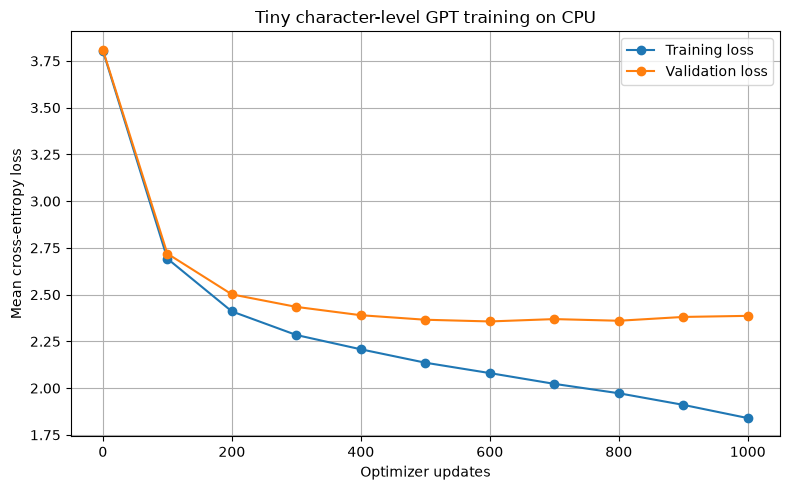

training loss decreased: True
validation loss decreased: True


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    evaluation_steps,
    training_loss_history,
    marker="o",
    label="Training loss",
)
plt.plot(
    evaluation_steps,
    validation_loss_history,
    marker="o",
    label="Validation loss",
)
plt.xlabel("Optimizer updates")
plt.ylabel("Mean cross-entropy loss")
plt.title("Tiny character-level GPT training on CPU")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("training loss decreased:", end=" ")
print(training_loss_history[-1] < training_loss_history[0])
print("validation loss decreased:", end=" ")
print(validation_loss_history[-1] < validation_loss_history[0])

A decreasing training loss shows that the optimizer improved predictions on sampled training windows.

Validation behavior is the more relevant signal for the held-out substring and may be less smooth.


## Compare generation before and after training

Using the same prompt and sampling seed makes differences attributable to learned parameters rather than a different random token sequence.


In [12]:
print("before training:")
print(generated_samples[0])
print()
print("after 500 updates:")
print(generated_samples[500])
print()
print("after 1,000 updates:")
print(generated_samples[1000])

before training:
AlicepSeO;

g krT
fp?lt!e lhd.xppf-lpieBo?Avl;wOcenObtuEtg;pdnBcIrhn
,usbIrysBn?t?.yETB
hdp 
Ordltsc,l,?,hbayorpdwBSd?wgT lshlnhI;
bt,ITvyb
Ic-pm!b-sEtO?lBn!Tvy
tuOg

after 500 updates:
Alice te ar
g srer pileee linonlif d ie or wisthotong bbt theng trend, s ar s tel . wad he harrr tocth, a say, pd dade d t shenhat
cenghay o thping setereler ve tupg

after 1,000 updates:
Alice to ar
g srer aile thlicong fo. ie or wisitot



Tht thengeters

The r sondo sy thehe harrr tour der say, pledade dy f henlfaleenly sindindang shetof no ve tulg


The later samples should usually show more plausible local character patterns even when their meaning remains weak or repetitive.


## Inspect a trained validation batch

Training changes parameter values without changing the model's input, target, or logit shapes.


In [13]:
validation_generator = torch.Generator(device=device).manual_seed(7104)
validation_input, validation_target = get_gpt_training_batch(
    validation_token_ids,
    batch_size=2,
    context_length=context_length,
    generator=validation_generator,
)
previous_training_mode = model.training
model.eval()
with torch.no_grad():
    validation_logits, validation_loss = model(validation_input, validation_target)
model.train(previous_training_mode)

print("validation input shape:", validation_input.shape)
print("validation target shape:", validation_target.shape)
print("validation logit shape:", validation_logits.shape)
print("validation batch loss:", end=" ")
print(validation_loss.item() if validation_loss is not None else None)
print("decoded validation input:")
print(repr(decode_token_ids(validation_input[0].tolist(), id_to_character)))
print("decoded validation target:")
print(repr(decode_token_ids(validation_target[0].tolist(), id_to_character)))

validation input shape: torch.Size([2, 64])
validation target shape: torch.Size([2, 64])
validation logit shape: torch.Size([2, 64, 38])
validation batch loss: 2.4226527214050293
decoded validation input:
'ery slowly, for she had plenty of\ntime as she went down to look '
decoded validation target:
'ry slowly, for she had plenty of\ntime as she went down to look a'


The held-out target still follows the same one-character shift used for training.


## Training and evaluation modes

`model.train()` enables dropout for parameter-update batches.

`model.eval()` disables dropout for repeatable loss estimates and generation.

`torch.no_grad()` prevents graph construction during evaluation and generation, reducing memory and computation.

These controls do not freeze or unfreeze parameters by themselves.


## Why early samples remain messy

The model is small, the source text is short, and every generated character becomes input for later predictions.

One unlikely sample can move generation into a context unlike the training data and compound later errors.

Repeated source substrings also encourage memorized fragments rather than broad language understanding.

Sample quality is therefore a qualitative demonstration, while held-out loss is the more controlled measurement.


## Troubleshooting checklist

If loss does not decrease, verify:

- `target_batch[:, :-1]` equals `input_batch[:, 1:]`;
- causal masking remains active;
- the optimizer received `model.parameters()`;
- `optimizer.zero_grad()` runs before `loss.backward()`;
- `optimizer.step()` runs after backpropagation;
- the learning rate is nonzero; and
- training runs in `model.train()` mode.

If evaluation is noisy, use more fixed evaluation batches at the cost of additional CPU work.


## Common mistakes

- Do not repeat the full text before making a contiguous train-validation split.
- Do not train on targets equal to inputs.
- Do not remove causal masking.
- Do not apply softmax before cross-entropy.
- Do not forget to clear gradients before backpropagation.
- Do not evaluate with dropout enabled.
- Do not let evaluation or generation randomness silently alter training batches.
- Do not count a baseline evaluation as an optimizer update.
- Do not judge a production architecture by this tiny model's prose quality.


## Takeaways

A complete character-level GPT training step is:

```python
input_batch, target_batch = get_gpt_training_batch(...)
_, loss = model(input_batch, target_batch)
optimizer.zero_grad(set_to_none=True)
loss.backward()
optimizer.step()
```

Training mode enables dropout, while evaluation mode and `no_grad` make validation and generation stable and cheaper.

Fixed evaluation windows make loss checkpoints more comparable.

Separate random generators prevent reporting code from changing the training sequence.

> A falling loss demonstrates learning even when short samples from a tiny CPU model remain messy.


## What comes next

The next chapter will study autoregressive generation from a trained character model one token at a time.

It will make context cropping, final-position logits, sampling, and prompt constraints explicit.
